![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte A: Fundamentos de PyTorch

**Asignatura:** Redes Neuronales Profundas
**Bloque:** 1 — Fundamentos de Deep Learning

---

## Introducción

PyTorch es el framework de deep learning más utilizado en investigación y se está volviendo dominante también en la industria. Toda red neuronal en PyTorch —sin importar su complejidad— se construye sobre un único concepto fundamental: el **tensor**.

Este trabajo práctico tiene como objetivo que te familiarices con las operaciones sobre tensores que más se usan en el día a día del deep learning:

- Crear y explorar tensores
- Cambiar su forma en memoria (`reshape`, `view`, `unsqueeze`)
- Entender cómo PyTorch opera tensores de distintas formas (*broadcasting*)
- Calcular derivadas automáticamente con `autograd`

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Para resolver cada ejercicio, consultá el material teórico de la Clase 1.
- **No está permitido usar bucles `for` o `while` salvo que el enunciado lo indique explícitamente.**

In [ ]:
import torch
print(f"Versión de PyTorch: {torch.__version__}")

Versión de PyTorch: 2.10.0+cpu


---
## Sección A: Creación y atributos de tensores

### Ejercicio 1 — Creación y exploración de un tensor tridimensional

**Objetivo:** Entender cómo se estructura la información en tensores de varias dimensiones y qué atributos los describen.

**Enunciado:**

1. Inicializá un tensor tridimensional lleno de **ceros** con forma `(2, 3, 4)` — es decir, 2 bloques, 3 filas y 4 columnas. Utilizar la función de PyTorch diseñada para esto.
2. A partir de ese tensor, creá otro tensor con **valores aleatorios** (entre 0 y 1) que tenga exactamente la misma forma, usando la función `*_like` correspondiente.
3. Imprimí por pantalla los siguientes atributos del tensor aleatorio:
- Su forma (`.shape`)
- Su tipo de dato (`.dtype`)
- Su número de dimensiones (`.ndim`)
- La cantidad total de elementos (`.numel()`)



In [ ]:
tensor = torch.zeros((2,3,4))
tensor1 = torch.rand_like(tensor)
print(tensor1.shape)
print(tensor1.shape)
print(tensor1.ndim)
print(tensor1.numel())


torch.Size([2, 3, 4])
torch.Size([2, 3, 4])
3
24


**Pregunta de análisis:**

¿Qué diferencia hay entre `torch.zeros(2, 3, 4)` y `torch.empty(2, 3, 4)`? ¿En qué situación usarías cada uno?

Empty si queremos velocidad y está garazantizado que los valores random serán actualizados

### Ejercicio 2 — Tipos de dato y conversión

**Objetivo:** Comprender que los tensores tienen un tipo de dato numérico subyacente y que elegirlo bien tiene consecuencias en precisión y rendimiento.

**Enunciado:**

1. Creá un tensor de números aleatorios con forma `(3, 3)` con el tipo de dato por defecto (`float32`).
2. Convertilo a `float16`.
3. Imprimí ambos tensores y sus respectivos `dtype`.
4. Volvé a convertir el tensor de `float16` nuevamente a `float32`. Luego, calculá la diferencia (resta) entre el tensor original y este último. Observá si los valores de la resta son exactamente cero o si hay pequeñas diferencias.


In [ ]:
# Tu código aquí
tensor = torch.rand(3,3).type(torch.float32)
tensor1 = tensor.type(torch.float16)
print(tensor,tensor.dtype)
print(tensor1,tensor1.dtype)

diff = tensor - tensor1.type(torch.float32)
print(diff)

tensor([[0.5172, 0.5675, 0.7605],
        [0.3617, 0.2448, 0.4214],
        [0.9214, 0.1870, 0.8315]]) torch.float32
tensor([[0.5171, 0.5674, 0.7607],
        [0.3618, 0.2448, 0.4214],
        [0.9214, 0.1870, 0.8315]], dtype=torch.float16) torch.float16
tensor([[ 9.1195e-05,  7.5221e-05, -2.0057e-04],
        [-9.2149e-05,  2.3901e-05,  5.7817e-06],
        [ 1.2219e-05, -1.7583e-05, -2.9504e-05]])


**Pregunta de análisis:**

`float16` usa la mitad de memoria que `float32`. ¿Por qué, aun con esa ventaja, no siempre es conveniente entrenar redes en `float16`? ¿Qué riesgo implica la menor precisión numérica?

El riesgo es que aparezcan underflows. Esto se da por ejemplo, con números muy pequeños cercanos a 0 que al usar float16 se redondean a 0.

---
## Sección B: Cambio de forma — `reshape` y `view`

### Ejercicio 3 — Reorganización bidimensional y orden de llenado

**Objetivo:** Analizar en qué orden PyTorch acomoda los elementos al cambiar la forma de un tensor.

**Enunciado:**

1. Creá un tensor unidimensional con los números del 1 al 12.
2. Reorganizálo en una matriz de **3 filas × 4 columnas** usando `reshape()`.
3. Imprimí la matriz e identificá en qué fila y columna quedó el número `8`.
4. Ahora reorganizá el mismo vector original en una matriz de **4 filas × 3 columnas** y comparálo con el resultado anterior.

> **Funciones a utilizar:** `torch.arange()` y `.reshape()`.

In [ ]:
# Tu código aquí
uni = torch.arange(1,13)
print(uni)
matrix =  uni.reshape(3,4)
print(matrix)
matrix2 = uni.reshape(4,3)
print(matrix2)

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])


**Pregunta de análisis:**

¿En qué orden llena PyTorch los elementos al hacer un `reshape`? ¿Cómo se denomina esa convención? (Pista: es la misma que usa NumPy y Python por defecto.)

Pytorch llena los elementos fila por fila. Esta convención se llama C-Order

### Ejercicio 4 — Orden de llenado en cuatro dimensiones (Tensores 4D)

**Objetivo:** Extender el concepto del orden de llenado a tensores de 4 dimensiones, como los frecuentemente usados para lotes de imágenes: `(lotes, canales, filas, columnas)`.

**Enunciado:**

1. Creá un tensor unidimensional con los números del 1 al 24.
2. Reorganizálo en un tensor 4D con forma `(2, 3, 2, 2)`. Es decir: 2 lotes (batches), 3 canales, 2 filas y 2 columnas.
3. Imprimí el tensor e identificá el patrón de llenado. ¿Qué dimensiones se completan primero y cuáles últimas?
4. Extraé el valor almacenado en la posición `[lote 1, canal 2, fila 0, columna 1]` (recordando que los índices empiezan en 0) usando indexación, por ejemplo: `tensor[1, 2, 0, 1]`.
5. Verificá analíticamente si el valor extraído coincide con lo esperado.


In [ ]:
# Tu código aquí
uni = torch.arange(1,25)
tensor = uni.reshape(2,3,2,2)
print(tensor)
print(tensor[1,2,0,1]) ## El 22 coincide con lo esperado


tensor([[[[ 1,  2],
          [ 3,  4]],

         [[ 5,  6],
          [ 7,  8]],

         [[ 9, 10],
          [11, 12]]],


        [[[13, 14],
          [15, 16]],

         [[17, 18],
          [19, 20]],

         [[21, 22],
          [23, 24]]]])
tensor(22)


**Pregunta de análisis:**

En un tensor de forma `(lotes, canales, filas, columnas)`, ¿qué dimensión varía más rápido en memoria (es decir, qué elementos son adyacentes) y cuál más lento?

La dimensión que más rápido varia en memeoria es la ultima, en este caso las columnas. Para movernos de una columna a otra solo tenemos que avanzar 1 en memoria.

### Ejercicio 5 — `view` en un tensor tridimensional

**Objetivo:** Extender el concepto de reorganización a tres dimensiones y practicar la indexación de tensores.

**Enunciado:**

1. Creá un tensor unidimensional con los números del 0 al 23.
2. Usá el método `.view()` para darle la forma `(2, 3, 4)`.
3. Extraé e imprimí el **primer bloque** (índice 0 de la primera dimensión).
*¿Qué forma tiene ese bloque?*
4. Sin usar bucles, identificá en qué posición `[bloque, fila, columna]` quedó el número `15`.

> **Pista:** Podés indexar un tensor tridimensional con tres índices: `tensor[bloque, fila, columna]`. Para encontrar el 15, podés calcularlo a mano usando el orden de llenado que aprendiste en el ejercicio anterior.

In [ ]:
# Tu código aquí
uni = torch.arange(24)
tensor = uni.view(2,3,4)
print(tensor[0]) # tiene forma 3 filas x 4 columnas

quinceBloque = 15 // (3*4) # división entera para saber en qué bloque cae el 15 -> 1,25 -> 1 (o sea, lo divimos por el tamaño del bloque)
quinceFila = (15 % (3*4)) // 4 # el resto que queda, (0,25) lo dividimos entre 4 -> 0,0625 -> 0 -> sabemos que está en la fila 0
quinceColumna = 15 % 4 # // con esta operación sabemos en qué columna cae.
print(quinceBloque, quinceFila, quinceColumna)
quince = tensor[quinceBloque,quinceFila,quinceColumna]
print(quince)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
1 0 3
tensor(15)


### Ejercicio 6 — Memoria compartida y `.clone()`

**Objetivo:** Entender que `view` y `reshape` no copian los datos en memoria, sino que crean una *vista* sobre los mismos datos. Aprender a hacer una copia real con `.clone()`.

**Parte A — La vista comparte memoria:**

1. Utilizá el vector de 24 elementos del Ejercicio 5 y su versión con forma `(2, 3, 4)` (el tensor cúbico).
2. Modificá el **primer elemento** del vector original asignándole el valor `-99`.
3. Imprimí el tensor cúbico y observá si también cambió.

**Parte B — Copiar con `.clone()`:**

4. Creá una copia *real* del tensor cúbico usando `.clone()`.
5. Modificá ahora el segundo elemento del vector original (asignale `-999`).
6. Imprimí la copia: esta vez **no** debería reflejar el cambio.

**Pista:** Un tensor creado con `view` o `reshape` a partir de otro comparte la misma zona de memoria. Cualquier modificación al original se refleja en todas sus vistas — a menos que uses `.clone()` para crear una copia independiente.

In [ ]:
uni[0] = -99
print(tensor)

tensor([[[-99,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23]]])


In [ ]:
# Tu código aquí — Parte B
cloned = tensor.clone()
uni[1] = -999
print(cloned)


tensor([[[-99,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23]]])


**Pregunta de análisis:**

¿Qué ventaja de rendimiento tiene el hecho de que `view` y `reshape` no copien datos? ¿En qué situación sería un problema que dos tensores compartan la misma memoria, y cómo lo solucionarías?

Al no copiar datos, ahorramos espacio en memoria y las operaciones son más rápidas que clonarlos

---
## Sección C: Broadcasting

### Introducción al broadcasting

El *broadcasting* es la capacidad de PyTorch (heredada de NumPy) de operar matemáticamente sobre tensores de **distintas formas**, sin copiar datos en memoria. PyTorch compara las dimensiones de los dos tensores **de derecha a izquierda** y aplica las siguientes reglas para cada par de dimensiones:

| Situación | Resultado |
|---|---|
| Ambas dimensiones son iguales | Se opera normalmente |
| Una de las dimensiones es `1` | Se "expande" virtualmente |
| Una dimensión no existe | Se trata como si fuera `1` |
| Distintas y ninguna es `1` | Error |

Esto es fundamental en deep learning: por ejemplo, cuando se suma un vector de *biases* a toda una matriz de activaciones, se usa broadcasting.

### Ejercicio 7 — Broadcasting elemental

**Objetivo:** Observar la regla más simple de broadcasting: un vector sobre las filas de una matriz.

**Enunciado:**

1. Creá una matriz `A` de forma `(3, 4)` llena de unos.
2. Creá un vector `v` de 4 elementos con los valores `[10, 20, 30, 40]`.
3. Calculá el producto `A * v` e imprimí el resultado.
4. Verificá que las reglas de broadcasting aplican: anotá las formas de `A` y `v` de derecha a izquierda y verificá si son compatibles.


In [ ]:
# Tu código aquí
A = torch.ones(3,4) # (3,4)
print(A)
V = torch.tensor([10,20,30,40]) # (1,4)
print(A*V)
# (3,4) vs (1,4) -> se compara de derecha a izq: 4 vs 4 son compatible. Luego 3 vs 1 también porque una de las dimensiones es 1


tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[10., 20., 30., 40.],
        [10., 20., 30., 40.],
        [10., 20., 30., 40.]])


**Pregunta de análisis:**

Verificá la compatibilidad comparando de derecha a izquierda las dimensiones de `A` (forma `(3, 4)`) y `v` (forma `(4)`):

```
A: 3 4
v: 4 ← la dimensión izquierda no existe, se trata como 1
```

¿Por qué el resultado final tiene forma `(3, 4)`?

Porque al hacer broadcasting las dimensiones se igualan a la de mayor tamaño

### Ejercicio 8 — Broadcasting con `reshape`/`unsqueeze` en tensores 3D

**Objetivo:** Adaptar dimensiones con `reshape` o `unsqueeze` para hacer compatible el broadcasting cuando las formas no coinciden naturalmente.

**Enunciado:**

Tenés un tensor `A` con forma `(3, 2, 4)` y un vector `v` con 6 elementos `[6, 5, 4, 3, 2, 1]`.

El objetivo es multiplicar `A * v` de manera que **cada fila de `A` se multiplique por el elemento correspondiente de `v`**:
- La fila 0 (del bloque 0) se multiplica por 6
- La fila 1 (del bloque 0) se multiplica por 5
- La fila 0 (del bloque 1) se multiplica por 4
- ... y así sucesivamente

Para lograr esto, necesitás reorganizar `v` para que PyTorch sepa cómo alinearlo con `A`.


**Pasos:**

1. Generá e imprimí `A` y `v` para entender qué forma tienen.
1. Reorganizá `v` para que sea compatible con `A` usando `reshape` o `unsqueeze`.
1. Realizá la multiplicación y verificá que cada fila fue multiplicada por el escalar correcto.

> **Pista:** El tensor `A` tiene 3 bloques de 2 filas cada uno (3 × 2 = 6 filas en total). Necesitás que `v` tenga una forma que se alinee con las dos primeras dimensiones de `A`, dejando una dimensión de tamaño 1 al final para que el broadcasting la expanda. Pensá qué forma de 3 dimensiones le darías a `v`.

In [ ]:
import torch
A = torch.arange(24).reshape(3,2,4)
v = torch.tensor([6,5,4,3,2,1])
print(A)
print(v)
print(A*v.view(3,2,1))

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7]],

        [[ 8,  9, 10, 11],
         [12, 13, 14, 15]],

        [[16, 17, 18, 19],
         [20, 21, 22, 23]]])
tensor([6, 5, 4, 3, 2, 1])
tensor([[[ 0,  6, 12, 18],
         [20, 25, 30, 35]],

        [[32, 36, 40, 44],
         [36, 39, 42, 45]],

        [[32, 34, 36, 38],
         [20, 21, 22, 23]]])


### Ejercicio 9 — Normalización de canales de imágenes

**Objetivo:** Aplicar broadcasting en un contexto completamente real: el pre-procesamiento de imágenes en deep learning.

**Contexto:** En visión por computadora, antes de entrenar una red con imágenes, se *normaliza* cada canal de color restándole su media histórica. Un lote de imágenes tiene forma `(N, C, H, W)` donde:
- `N` = cantidad de imágenes en el lote
- `C` = canales de color (3 para imágenes RGB: Rojo, Verde, Azul)
- `H` = alto de la imagen en píxeles
- `W` = ancho de la imagen en píxeles

**Enunciado:**

Tenés un lote de imágenes `X` con forma `(32, 3, 28, 28)`, esto es un lote de 32 imágenes de tres canales (RGB) de 28x28 píxeles. Utilizarás también un vector llamado `medias` de 3 componentes donde cada componente es la media de cada canal (RGB) del dataset completo.

Tu tarea es calcular la resta `X - medias` de forma que a todos los canales de color en **todas** las imágenes del lote se le reste la media correspondiente. Todo sin usar bucles.

1. Intentá directamente `X - medias` y observá el error que da PyTorch. Leélo con atención.
2. Reorganizá `medias` para que PyTorch pueda alinearlo con la dimensión de canales (dim 1) de `X`.
3. Calculá la resta correctamente y verificá que el resultado tiene forma `(32, 3, 28, 28)`.

> **Pista:** Las reglas de broadcasting van de **derecha a izquierda**. Si intentás `X - medias` directamente, PyTorch intentará alinear el `3` de `medias` con el `28` del ancho, lo que falla. Necesitás que `medias` tenga una forma con dimensiones de tamaño 1 en las posiciones que no corresponden al canal. Buscá `.view()` o `.unsqueeze()` para agregar dimensiones de tamaño 1.

In [ ]:
import torch
torch.manual_seed(42)
X = torch.rand(32, 3, 28, 28)
medias = torch.tensor([0.5, 0.4, 0.3])

try:
  X-medias
except RuntimeError as e:
  print(e)

medias = medias.view(1,3,1,1)
X_normalizado = X - medias
print(f"Forma normaliazada: {X_normalizado.shape}")


The size of tensor a (28) must match the size of tensor b (3) at non-singleton dimension 3
Forma normaliazada: torch.Size([32, 3, 28, 28])


**Pregunta de análisis:**

Describí paso a paso cómo quedan alineadas las dimensiones después de reorganizar `medias`. Completá la tabla:

```
X: 32 3 28 28
medias: 1 3 1 1
```

*(Completá los `?` con los tamaños reales de `medias` reorganizado)*

### Ejercicio 10 — Cuadrícula con broadcasting bidireccional

**Objetivo:** Usar broadcasting en dos ejes al mismo tiempo para generar una matriz de combinaciones.

**Enunciado:**

Tenés un vector `x` con los números del 1 al 5 y un vector `y` con los múltiplos de 10 del 10 al 40.

Generá una matriz `M` de dimensiones `(5, 4)` donde cada posición `(i, j)` contenga la suma:
$$M_{i,j} = x_i + y_j$$

**Todo debe resolverse en una sola línea de código, sin bucles y sin matrices intermedias vacías.**

> **Pista:** Para que el broadcasting cree una matriz de sumas, uno de los vectores debe expandirse hacia abajo (columna) y el otro hacia la derecha (fila). Transformá `x` en un tensor columna de forma `(5, 1)` usando `.unsqueeze(1)`. El vector `y` de forma `(4,)` equivale automáticamente a una fila `(1, 4)`. Al sumarlos, PyTorch generará la cuadrícula completa.

In [ ]:
import torch
x = torch.arange(1, 6) # [1, 2, 3, 4, 5]
y = torch.arange(10, 50, 10) # [10, 20, 30, 40]

# Tu código aquí: generá M en una sola línea
M = x.view(5,1) + y.view(1,4)
print(M)


tensor([[11, 21, 31, 41],
        [12, 22, 32, 42],
        [13, 23, 33, 43],
        [14, 24, 34, 44],
        [15, 25, 35, 45]])


---
## Sección D: Diferenciación automática con Autograd

### Introducción a Autograd

Una de las capacidades más importantes de PyTorch es su motor de **diferenciación automática**, llamado `autograd`. Cuando entrenamos una red neuronal, necesitamos calcular el gradiente de la función de pérdida con respecto a cada parámetro de la red. Hacer esto a mano para redes con millones de parámetros sería imposible.

PyTorch resuelve esto de forma elegante: a medida que realizás operaciones sobre tensores con `requires_grad=True`, PyTorch construye internamente un **grafo computacional** que registra qué operaciones se realizaron y en qué orden. Cuando llamás a `.backward()`, PyTorch recorre ese grafo al revés y calcula todos los gradientes automáticamente.

Después de llamar a `.backward()`, el grafo se libera de memoria por defecto (sólo se puede usar una vez).

### Ejercicio 11 — Gradiente automático y verificación analítica

**Objetivo:** Usar `autograd` para calcular una derivada y verificar el resultado con el cálculo analítico.

**Enunciado:**

1. Definí un tensor escalar `x = 2.0` e indicale a PyTorch que debe rastrear sus operaciones para calcular gradientes.
2. Calculá la función:
$$y = 3x^2 + 4x + 2$$
3. Ejecutá la propagación hacia atrás (`.backward()`) y extraé el valor del gradiente en `x`.
4. Verificá el resultado comparándolo con la derivada calculada analíticamente:
$$\frac{dy}{dx} = 6x + 4$$
evaluada en $x = 2$.
5. Intentá llamar a `.backward()` una segunda vez y observá el error. Luego volvé a calcular `y` usando `retain_graph=True` en el primer `.backward()` y verificá que ya no hay error.



In [ ]:
import torch

x = torch.tensor(2.0, requires_grad=True)

y = 3 * x**2 + 4 * x + 2

y.backward(retain_graph=True)

print("Gradiente calculado por autograd:", x.grad.item())

print(x.grad.item() == 6 * 2 +4)

Gradiente calculado por autograd: 16.0
True


In [ ]:
y.backward()


**Pregunta de análisis:**

1. ¿Qué es el **grafo computacional** que construye PyTorch? ¿Por qué se libera automáticamente después de llamar a `.backward()`?
2. ¿Para qué sirve `retain_graph=True`? ¿Investiga en qué situación real podría necesitarse calcularlo más de una vez?

El grafo computacional es la estructura de datos que genera y utiliza Pytorch para guardar qué operaciones se ejecutaron sobre cada tensor y luego poder calcular la derivada sobre el nodo final.
Si no utilizamos retain_graph=True, perdemos el grafo generado por lo tanto no podemos calcular las derivadas nuevamente   

---
## Sección E: Datasets personalizados con `torch.utils.data.Dataset`

Para entrenar redes con datos propios, PyTorch requiere que los encapsulés en una clase que herede de `torch.utils.data.Dataset`. Basta con implementar tres métodos:

| Método | Responsabilidad |
|---|---|
| `__init__` | Cargar metadatos, CSV, lista de rutas — lo que sea necesario para encontrar los datos |
| `__len__` | Devolver la cantidad total de elementos |
| `__getitem__(i)` | Cargar y retornar el elemento en la posición `i` |

Una vez que tu clase implementa esta interfaz, podés pasarla directamente a un `DataLoader` para obtener lotes, mezclado y carga paralela sin escribir código adicional.

In [12]:
# Descarga del dataset — ejecutar una sola vez
# Requiere: pip install gdown
#!gdown https://drive.google.com/uc?id=1FMkstj2JgQOySU0D6mH7Dtr-hts2cqSD
#!unzip -q ./data/plates.zip -d ./data/plates
!mv "./data/plates/new plates/plates.csv" ./data/plates

### Ejercicio 12 — Creación de un Dataset personalizado

**Objetivo:** Implementar la interfaz `torch.utils.data.Dataset` para cargar un conjunto de datos propio desde archivos en disco.

**Contexto:** Trabajarás con un dataset de imágenes de placas de matrícula de distintos estados de EE.UU. El archivo `plates.csv` tiene la siguiente estructura:

| Columna | Descripción |
|---|---|
| `class id` | Identificador numérico del estado |
| `filepaths` | Ruta relativa a la imagen |
| `labels` | Nombre del estado (ej. `ALABAMA`) |
| `data set` | Partición: `train`, `test` o `val` |

**Enunciado:**

Completá la clase `PlatesDataSet` que hereda de `torch.utils.data.Dataset`:

1. `__init__`: leé el CSV con `pandas`, filtrá las filas según el valor de `mode` (`'train'`, `'test'` o `'val'`), y almacená las rutas, etiquetas numéricas y etiquetas de texto en atributos de la instancia.
2. `__len__`: retorná la cantidad de imágenes en la partición seleccionada.
3. `__getitem__(index)`: construí la ruta completa con `os.path.join()`, cargá la imagen con `PIL.Image.open()`, aplicá `transform` si fue provisto, y retorná el par `(imagen, etiqueta_numérica)`.
4. `get_class_name(index)`: retorná el nombre del estado (etiqueta de texto) para el elemento en `index`. Este método es necesario para la función de visualización.

> **Pistas:**
> - Usá `pd.read_csv()` para leer el CSV y filtrá con `df[df['data set'] == mode].reset_index(drop=True)`.
> - Recordá llamar a `super().__init__()` en el constructor.
> - En `__getitem__`, usá `.convert('RGB')` para garantizar 3 canales independientemente del formato de la imagen.

In [16]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms


class PlatesDataSet(Dataset):
    def __init__(self, csv_file='./data/plates/plates.csv', root_dir='./data/plates',
                 mode='train', transform=None):
        """
        Parámetros:
        csv_file (str): ruta al archivo CSV con las anotaciones
        root_dir (str): directorio raíz que contiene las imágenes
        mode (str): partición a cargar ('train', 'test' o 'val')
        transform: transformaciones opcionales a aplicar a las imágenes
        """
        super().__init__()
        dataframe = pd.read_csv(csv_file)
        ## filtrar todos los datos que sean "train"
        self.data = dataframe[dataframe['data set'] == mode].reset_index(drop=True)
        self.labels = self.data['class id'].tolist()
        self.root_dir = root_dir
        self.transform = transform
        self.text_labels = self.data['labels'].tolist()
        self.filepaths = self.data['filepaths'].tolist()

    def __len__(self):
        """Retorna la cantidad de imágenes en la partición."""
        return len(self.data)

    def __getitem__(self, index):
        """
        Retorna la imagen y la etiqueta en la posición index.

        Retorna:
        tuple: (imagen, etiqueta_numérica)
        """
        # Tu código aquí
        img_path = os.path.join(self.root_dir, self.filepaths[index])
        image = Image.open(img_path).convert('RGB')
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_class_name(self, index):
        """Retorna el nombre del estado para el elemento en index."""
        # Tu código aquí
        return self.text_labels[index]

Imágenes de entrenamiento: 8161


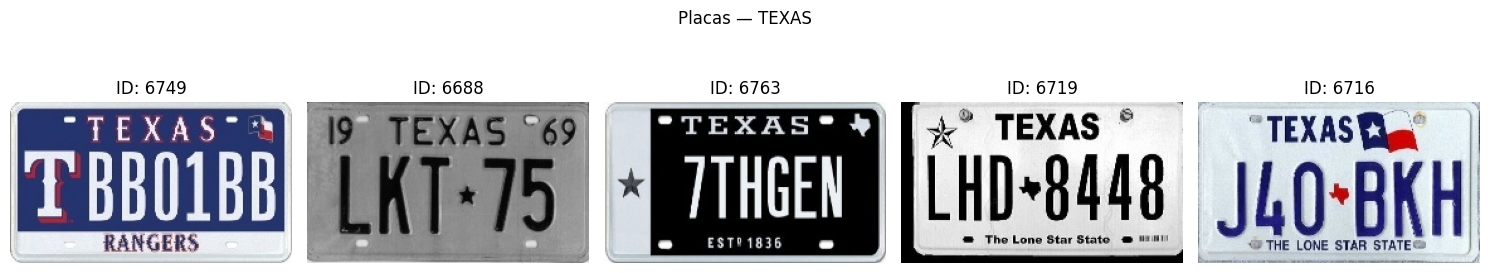

In [20]:
# Función de visualización y test — ejecutar sin modificar
import matplotlib.pyplot as plt
import random
import numpy as np

def visualize_state_plates(dataset, state_name, num_examples=5):
    """
    Muestra ejemplos de placas de un estado específico del dataset.

    Parámetros:
    dataset (PlatesDataSet): dataset de placas de matrícula
    state_name (str): nombre del estado en mayúsculas (ej. 'NEW YORK')
    num_examples (int): cantidad de imágenes a mostrar
    """
    indices = [i for i in range(len(dataset))
               if dataset.get_class_name(i).upper() == state_name.upper()]

    if not indices:
        available = sorted(set(dataset.text_labels))
        print(f"No se encontraron imágenes para '{state_name}'.")
        print(f"Estados disponibles: {', '.join(available)}")
        return

    selected = random.sample(indices, min(num_examples, len(indices)))
    fig, axes = plt.subplots(1, len(selected), figsize=(len(selected) * 3, 3))
    if len(selected) == 1:
        axes = [axes]

    for i, idx in enumerate(selected):
        image, _ = dataset[idx]
        img_np = image.permute(1, 2, 0).numpy() if isinstance(image, torch.Tensor) else np.array(image)
        axes[i].imshow(img_np)
        axes[i].set_title(f"ID: {idx}")
        axes[i].axis('off')

    plt.suptitle(f"Placas — {state_name.upper()}", y=1.02)
    plt.tight_layout()
    plt.show()


# Probar el dataset con el estado 'NEW YORK'
dataset_train = PlatesDataSet(mode='train', transform=transforms.ToTensor())
print(f"Imágenes de entrenamiento: {len(dataset_train)}")
visualize_state_plates(dataset_train, 'TEXAS')

**Pregunta de análisis:**

¿Por qué PyTorch separa la lógica del dataset (`Dataset`) de la lógica del iterador por lotes (`DataLoader`)? ¿Qué ventaja tiene este diseño a la hora de experimentar con distintos tamaños de lote o estrategias de mezclado de datos?

Porque de esta forma Pytorch separa la lógica para representación de datos de la lógica para iterarlos.

---
## ¡Listo!

Completaste el Laboratorio 1a. En el próximo laboratorio usaremos todos estos conceptos como base para construir y entrenar redes neuronales reales sobre datos de imágenes.